# 📷 Traffic Sign Classifier — Notebook 2: Nhận diện realtime qua Webcam

---

**Mục tiêu:** Sử dụng model đã train để nhận diện biển báo giao thông **trực tiếp từ webcam** theo thời gian thực.

**Pipeline:**
```
📷 Webcam Frame  →  ✂️ Cắt vùng ROI  →  🔄 Resize 30×30  →  🧠 Predict  →  🖥️ Hiển thị kết quả
```

| Thông số | Giá trị |
|---|---|
| Vùng quét ROI | 200×200 px (chính giữa frame) |
| Ngưỡng tin cậy hiển thị | ≥ 70% |
| Phím tắt | `Q` thoát  \|  `S` chụp ảnh |
| Độ phân giải camera | 1280×720 |

---
> ⚠️ **Yêu cầu:** File `traffic_classifier.h5` phải nằm cùng thư mục với notebook này.

## 📦 Bước 0 — Kiểm tra thư viện & thiết bị

In [13]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from IPython.display import display, clear_output
import ipywidgets as widgets

# Kiểm tra thư viện
print(f"✅ OpenCV version : {cv2.__version__}")
print(f"✅ NumPy version  : {np.__version__}")

# Kiểm tra camera
print("\n🔍 Kiểm tra camera khả dụng:")
for idx in range(4):
    cap = cv2.VideoCapture(idx)
    if cap.isOpened():
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        print(f"   ✅ Camera index {idx}: {w}×{h}")
    cap.release()

# Kiểm tra model
MODEL_PATH = "traffic_classifier.h5"
if os.path.exists(MODEL_PATH):
    size_mb = os.path.getsize(MODEL_PATH) / 1024 / 1024
    print(f"\n✅ Model tìm thấy: {MODEL_PATH}  ({size_mb:.1f} MB)")
else:
    print(f"\n❌ Không tìm thấy: {MODEL_PATH}")
    print("   Hãy chạy notebook 01_Train.ipynb trước!")

✅ OpenCV version : 4.8.1
✅ NumPy version  : 1.26.4

🔍 Kiểm tra camera khả dụng:

✅ Model tìm thấy: traffic_classifier.h5  (18.7 MB)


## 🧠 Bước 1 — Load model

In [14]:
from tensorflow.keras.models import load_model

print("⏳ Đang tải model...")
model = load_model(MODEL_PATH)
print("✅ Model sẵn sàng!")
print(f"   Input shape  : {model.input_shape}")
print(f"   Output shape : {model.output_shape}")
print(f"   Tổng params  : {model.count_params():,}")

c:\Users\Lactv\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


⏳ Đang tải model...


✅ Model sẵn sàng!
   Input shape  : (None, 30, 30, 3)
   Output shape : (None, 43)
   Tổng params  : 1,625,579


## ⚙️ Bước 2 — Cấu hình hệ thống

In [15]:
# ─── CẤU HÌNH — chỉnh sửa tại đây ──────────────────────────────────
IMG_SIZE    = 30     # Kích thước ảnh model nhận vào (30×30)
CONF_THRESH = 0.70   # Ngưỡng độ tự tin: hiển thị kết quả nếu >= 70%
CAM_INDEX   = 0      # 0 = webcam mặc định, đổi thành 1/2 nếu có nhiều camera
ROI_SIZE    = 200    # Vùng quét (pixel) ở chính giữa màn hình
# ────────────────────────────────────────────────────────────────────

CLASS_NAMES = {
    0: "Gioi han toc do 20km/h",   1: "Gioi han toc do 30km/h",
    2: "Gioi han toc do 50km/h",   3: "Gioi han toc do 60km/h",
    4: "Gioi han toc do 70km/h",   5: "Gioi han toc do 80km/h",
    6: "Het gioi han 80km/h",      7: "Gioi han toc do 100km/h",
    8: "Gioi han toc do 120km/h",  9: "Cam vuot",
    10: "Cam vuot xe >3.5T",       11: "Uu tien nga tu",
    12: "Duong uu tien",           13: "Nhuong duong",
    14: "Dung lai (STOP)",         15: "Cam xe co",
    16: "Cam xe tai >3.5T",        17: "Cam vao",
    18: "Chu y nguy hiem",         19: "Cua trai nguy hiem",
    20: "Cua phai nguy hiem",      21: "Duong cong lien tiep",
    22: "Duong go ghe",            23: "Duong tron truot",
    24: "Duong hep ben phai",      25: "Cong trinh duong bo",
    26: "Co tin hieu den",         27: "Nguoi di bo",
    28: "Tre em qua duong",        29: "Xe dap qua duong",
    30: "Chu y bang/tuyet",        31: "Thu hoang qua duong",
    32: "Het moi gioi han",        33: "Re phai phia truoc",
    34: "Re trai phia truoc",      35: "Di thang",
    36: "Di thang hoac re phai",   37: "Di thang hoac re trai",
    38: "Giu ben phai",            39: "Giu ben trai",
    40: "Vong xuyen bat buoc",     41: "Het cam vuot",
    42: "Het cam vuot xe >3.5T",
}

print("✅ Cấu hình đã load:")
print(f"   IMG_SIZE    = {IMG_SIZE} px")
print(f"   CONF_THRESH = {CONF_THRESH*100:.0f}%")
print(f"   CAM_INDEX   = {CAM_INDEX}")
print(f"   ROI_SIZE    = {ROI_SIZE} px")
print(f"   Số class    = {len(CLASS_NAMES)}")

✅ Cấu hình đã load:
   IMG_SIZE    = 30 px
   CONF_THRESH = 70%
   CAM_INDEX   = 0
   ROI_SIZE    = 200 px
   Số class    = 43


## 🔍 Bước 3 — Giải thích hàm predict_frame

Hàm nhận **vùng ảnh BGR** (từ OpenCV) → trả về `(class_id, confidence)`

In [16]:
def predict_frame(model, roi_bgr):
    """
    Dự đoán class của vùng ảnh ROI.

    Tham số:
        model   : Keras model đã load
        roi_bgr : numpy array BGR từ OpenCV (bất kỳ kích thước)

    Trả về:
        class_id   (int)   : ID của class có xác suất cao nhất
        confidence (float) : Xác suất của class đó (0.0 – 1.0)
    """
    # Bước 1: BGR → RGB (OpenCV dùng BGR, model cần RGB)
    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)

    # Bước 2: Resize về 30×30
    roi_resized = cv2.resize(roi_rgb, (IMG_SIZE, IMG_SIZE))

    # Bước 3: Normalize [0,255] → [0,1] và thêm batch dimension
    arr = np.expand_dims(roi_resized / 255.0, axis=0)  # shape: (1, 30, 30, 3)

    # Bước 4: Predict — lấy softmax output
    preds = model.predict(arr, verbose=0)[0]            # shape: (43,)

    # Bước 5: Lấy class có xác suất cao nhất
    class_id   = int(np.argmax(preds))
    confidence = float(preds[class_id])

    return class_id, confidence

print("✅ Hàm predict_frame đã định nghĩa")

✅ Hàm predict_frame đã định nghĩa


### 🧪 Test predict_frame với ảnh giả

In [17]:
# Tạo ảnh giả ngẫu nhiên 200×200 BGR để test pipeline
dummy_roi = np.random.randint(0, 255, (200, 200, 3), dtype=np.uint8)

class_id, confidence = predict_frame(model, dummy_roi)

print(f"🧪 Test với ảnh ngẫu nhiên 200×200:")
print(f"   Class ID    : {class_id}")
print(f"   Class name  : {CLASS_NAMES.get(class_id, '???')}")
print(f"   Confidence  : {confidence*100:.2f}%")
print(f"   Hiển thị?   : {'✅ Có' if confidence >= CONF_THRESH else '❌ Dưới ngưỡng — Đang phân tích...'}")

🧪 Test với ảnh ngẫu nhiên 200×200:
   Class ID    : 40
   Class name  : Vong xuyen bat buoc
   Confidence  : 28.70%
   Hiển thị?   : ❌ Dưới ngưỡng — Đang phân tích...


## 🎨 Bước 4 — Giải thích hàm draw_overlay

Hàm vẽ **khung ROI + nhãn kết quả** lên frame video.

In [18]:
def draw_overlay(frame, class_id, confidence, roi_x1, roi_y1, roi_x2, roi_y2):
    """Vẽ khung ROI và kết quả nhận diện lên frame."""
    h, w = frame.shape[:2]

    # Chọn màu theo độ tự tin:
    #   >= CONF_THRESH → xanh lá (tin cậy)
    #   <  CONF_THRESH → cam     (chưa chắc)
    if confidence >= CONF_THRESH:
        box_color = (0, 200, 80)
        label = f"{CLASS_NAMES.get(class_id, '???')}  {confidence*100:.1f}%"
    else:
        box_color = (0, 150, 255)
        label = f"Dang phan tich...  {confidence*100:.1f}%"

    # Vẽ hình chữ nhật bao quanh ROI
    cv2.rectangle(frame, (roi_x1, roi_y1), (roi_x2, roi_y2), box_color, 2)

    # Vẽ góc trang trí (L-shape corners)
    corner = 20
    for (cx, cy, dx, dy) in [
        (roi_x1, roi_y1,  1,  1),   # Góc trên trái
        (roi_x2, roi_y1, -1,  1),   # Góc trên phải
        (roi_x1, roi_y2,  1, -1),   # Góc dưới trái
        (roi_x2, roi_y2, -1, -1),   # Góc dưới phải
    ]:
        cv2.line(frame, (cx, cy), (cx + dx*corner, cy), box_color, 3)
        cv2.line(frame, (cx, cy), (cx, cy + dy*corner), box_color, 3)

    # Vẽ nền nhãn (filled rectangle)
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale, thickness = 0.65, 2
    (tw, th), baseline = cv2.getTextSize(label, font, font_scale, thickness)
    label_x = roi_x1
    label_y = roi_y1 - 10 if roi_y1 - 10 > th + 6 else roi_y2 + th + 10

    cv2.rectangle(frame,
                  (label_x, label_y - th - 6),
                  (label_x + tw + 10, label_y + baseline),
                  box_color, -1)
    cv2.putText(frame, label, (label_x + 5, label_y - 3),
                font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

    # Gợi ý phím tắt ở góc dưới
    cv2.putText(frame, "Q: Thoat  |  S: Chup anh",
                (12, h - 12), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (180, 180, 180), 1, cv2.LINE_AA)

    return frame

print("✅ Hàm draw_overlay đã định nghĩa")

✅ Hàm draw_overlay đã định nghĩa


### 🖼️ Visualize ROI và cơ chế overlay

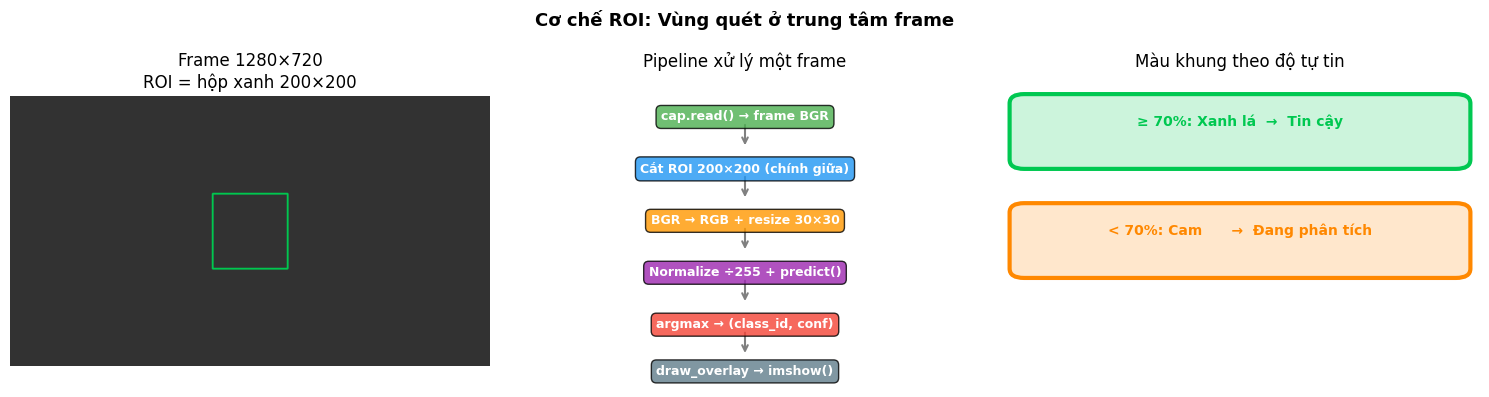

💾 Đã lưu: camera_pipeline.png


In [19]:
# Minh họa cách tính vùng ROI từ frame 1280×720
W, H = 1280, 720
ROI_SIZE_VIZ = 200

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Cơ chế ROI: Vùng quét ở trung tâm frame', fontsize=13, fontweight='bold')

# Frame đầy đủ
ax1 = axes[0]
frame_mock = np.ones((H, W, 3), dtype=np.uint8) * 50
cx, cy = W // 2, H // 2
half = ROI_SIZE_VIZ // 2
cv2.rectangle(frame_mock, (cx-half, cy-half), (cx+half, cy+half), (0, 200, 80), 3)
ax1.imshow(frame_mock)
ax1.set_title(f'Frame {W}×{H}\nROI = hộp xanh {ROI_SIZE_VIZ}×{ROI_SIZE_VIZ}')
ax1.axis('off')

# Luồng xử lý ROI
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 6)
ax2.axis('off')
ax2.set_title('Pipeline xử lý một frame')
steps = [
    (5, 5.2, 'cap.read() → frame BGR', '#4CAF50'),
    (5, 4.2, f'Cắt ROI {ROI_SIZE_VIZ}×{ROI_SIZE_VIZ} (chính giữa)', '#2196F3'),
    (5, 3.2, 'BGR → RGB + resize 30×30', '#FF9800'),
    (5, 2.2, 'Normalize ÷255 + predict()', '#9C27B0'),
    (5, 1.2, 'argmax → (class_id, conf)', '#F44336'),
    (5, 0.3, 'draw_overlay → imshow()', '#607D8B'),
]
for x, y, text, color in steps:
    ax2.annotate('', xy=(x, y-0.6), xytext=(x, y-0.1),
                 arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax2.text(x, y, text, ha='center', va='center', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.8),
             color='white', fontweight='bold')

# Màu sắc theo ngưỡng
ax3 = axes[2]
ax3.axis('off')
ax3.set_title('Màu khung theo độ tự tin')
levels = [
    (0.85, '≥ 70%: Xanh lá  →  Tin cậy', '#00C851'),
    (0.50, '< 70%: Cam      →  Đang phân tích', '#FF8800'),
]
for y_pos, text, color in levels:
    ax3.add_patch(mpatches.FancyBboxPatch((0.05, y_pos-0.12), 0.9, 0.18,
                  boxstyle="round,pad=0.03", linewidth=3,
                  edgecolor=color, facecolor=color+'33'))
    ax3.text(0.5, y_pos, text, ha='center', va='center',
             fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('camera_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: camera_pipeline.png")

## 🎥 Bước 5 — Chụp thử 1 frame từ camera

Test camera mà không cần mở vòng lặp đầy đủ.

In [20]:
cap = cv2.VideoCapture(CAM_INDEX)

if not cap.isOpened():
    print(f"❌ Không thể mở camera index={CAM_INDEX}")
    print("   Thay đổi CAM_INDEX ở Bước 2 và thử lại.")
else:
    ret, frame = cap.read()
    cap.release()

    if ret:
        h, w = frame.shape[:2]
        print(f"✅ Chụp thành công!  Frame size: {w}×{h}")

        # Tính ROI
        cx, cy = w // 2, h // 2
        half   = ROI_SIZE // 2
        roi_x1, roi_y1 = max(cx - half, 0), max(cy - half, 0)
        roi_x2, roi_y2 = min(cx + half, w), min(cy + half, h)
        roi = frame[roi_y1:roi_y2, roi_x1:roi_x2]

        # Predict
        class_id, confidence = predict_frame(model, roi)

        # Vẽ overlay
        frame_out = draw_overlay(frame.copy(), class_id, confidence,
                                 roi_x1, roi_y1, roi_x2, roi_y2)

        # Hiển thị trong notebook
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].imshow(cv2.cvtColor(frame_out, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'Frame với Overlay\nClass: {CLASS_NAMES.get(class_id)} | Conf: {confidence*100:.1f}%')
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'Vùng ROI ({ROI_SIZE}×{ROI_SIZE})')
        axes[1].axis('off')

        plt.tight_layout()
        plt.savefig('camera_test_frame.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"💾 Đã lưu: camera_test_frame.png")
        print(f"\n🎯 Dự đoán: {CLASS_NAMES.get(class_id, '???')}  ({confidence*100:.1f}%)")
    else:
        print("❌ Không đọc được frame từ camera.")

❌ Không thể mở camera index=0
   Thay đổi CAM_INDEX ở Bước 2 và thử lại.


## 🚀 Bước 6 — Vòng lặp realtime đầy đủ

> **Lưu ý:** Cell này mở cửa sổ OpenCV riêng. Nhấn **`Q`** để thoát, **`S`** để chụp ảnh.
>
> Trong Jupyter Lab, cửa sổ OpenCV có thể không hiển thị nếu chạy trên server từ xa — hãy dùng **GUI.py** hoặc **Camera.py** trực tiếp bằng terminal trong trường hợp đó.

In [21]:
def run_camera_loop(cam_index=CAM_INDEX, roi_size=ROI_SIZE):
    """Vòng lặp chính nhận diện biển báo realtime từ webcam."""

    cap = cv2.VideoCapture(cam_index)
    if not cap.isOpened():
        print(f"❌ Không thể mở camera index={cam_index}")
        return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

    print("📷 Camera đang chạy...")
    print("   Q → Thoát    S → Chụp ảnh")

    save_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            print("❌ Không đọc được frame.")
            break

        h, w = frame.shape[:2]

        # ── Tính vùng ROI chính giữa ──────────────────────────────
        cx, cy = w // 2, h // 2
        half   = roi_size // 2
        roi_x1 = max(cx - half, 0)
        roi_y1 = max(cy - half, 0)
        roi_x2 = min(cx + half, w)
        roi_y2 = min(cy + half, h)

        roi = frame[roi_y1:roi_y2, roi_x1:roi_x2]

        # ── Predict ───────────────────────────────────────────────
        class_id, confidence = predict_frame(model, roi)

        # ── Vẽ lên frame ──────────────────────────────────────────
        frame = draw_overlay(frame, class_id, confidence,
                             roi_x1, roi_y1, roi_x2, roi_y2)

        cv2.imshow("Nhan Dien Bien Bao — Q de thoat", frame)

        # ── Xử lý phím bấm ────────────────────────────────────────
        key = cv2.waitKey(1) & 0xFF
        if key in (ord('q'), ord('Q')):
            break
        elif key in (ord('s'), ord('S')):
            save_count += 1
            fname = f"capture_{save_count:03d}.jpg"
            cv2.imwrite(fname, frame)
            print(f"📸 Đã lưu: {fname}")

    cap.release()
    cv2.destroyAllWindows()
    print("✅ Đã đóng camera.")
    if save_count > 0:
        print(f"📁 Tổng ảnh đã chụp: {save_count}")


# Bỏ comment dòng dưới để chạy vòng lặp camera
# run_camera_loop()

print("✅ Hàm run_camera_loop đã định nghĩa")
print("   Bỏ comment dòng cuối để chạy!")

✅ Hàm run_camera_loop đã định nghĩa
   Bỏ comment dòng cuối để chạy!


## 📊 Bước 7 — Benchmark tốc độ dự đoán (FPS ước tính)

Đo thời gian xử lý mỗi frame để ước tính FPS thực tế.

⏱️  Benchmark 50 lần predict...

📊 Kết quả benchmark:
   Tổng thời gian   : 7.34s / 50 frames
   Thời gian/frame  : 146.8 ms
   FPS ước tính     : 6.8 FPS  (chỉ tính predict, chưa gồm overhead camera)


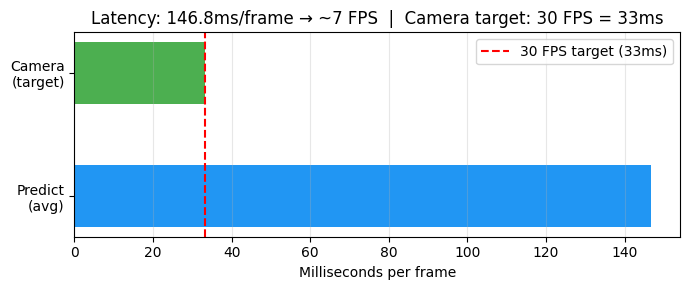

💾 Đã lưu: fps_benchmark.png


In [22]:
import time

N_RUNS = 50
dummy_frames = [
    np.random.randint(0, 255, (ROI_SIZE, ROI_SIZE, 3), dtype=np.uint8)
    for _ in range(N_RUNS)
]

print(f"⏱️  Benchmark {N_RUNS} lần predict...")
t0 = time.time()
for roi in dummy_frames:
    predict_frame(model, roi)
elapsed = time.time() - t0

avg_ms  = elapsed / N_RUNS * 1000
est_fps = 1000 / avg_ms

print(f"\n📊 Kết quả benchmark:")
print(f"   Tổng thời gian   : {elapsed:.2f}s / {N_RUNS} frames")
print(f"   Thời gian/frame  : {avg_ms:.1f} ms")
print(f"   FPS ước tính     : {est_fps:.1f} FPS  (chỉ tính predict, chưa gồm overhead camera)")

# Visualize
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(['Predict\n(avg)', 'Camera\n(target)'],
        [avg_ms, 1000/30],
        color=['#2196F3', '#4CAF50'], height=0.5)
ax.set_xlabel('Milliseconds per frame')
ax.set_title(f'Latency: {avg_ms:.1f}ms/frame → ~{est_fps:.0f} FPS  |  Camera target: 30 FPS = 33ms')
ax.axvline(x=1000/30, color='red', linestyle='--', label='30 FPS target (33ms)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fps_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: fps_benchmark.png")

## ✅ Tóm tắt

| Bước | Nội dung |
|---|---|
| 0 | Kiểm tra OpenCV + camera khả dụng |
| 1 | Load model từ `traffic_classifier.h5` |
| 2 | Cấu hình: ROI_SIZE, CONF_THRESH, CAM_INDEX |
| 3 | `predict_frame()`: BGR → RGB → resize → normalize → predict |
| 4 | `draw_overlay()`: Vẽ khung ROI + nhãn kết quả |
| 5 | Chụp thử 1 frame để xác nhận pipeline |
| 6 | Vòng lặp realtime đầy đủ (Q thoát, S chụp) |
| 7 | Benchmark FPS |

**Bước tiếp theo:** Mở notebook `03_GUI.ipynb` để tìm hiểu giao diện nhận diện từ ảnh.